# Анализ влияния рекламных бюджетов на продажи
## Цели проекта
1. Исследовать взаимосвязь между расходами на рекламу (`TV`, `Radio`, `Newspaper`) и объёмом продаж (`Sales`).
2. Проверить статистические предпосылки для применения линейной регрессии.
3. Построить и оценить прогнозирующие модели (простую и множественную).
4. Сформулировать бизнес-рекомендации по оптимизации маркетингового бюджета.

In [60]:
# Импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Загрузка и первичный осмотр данных
Датасет содержит данные о рекламных расходах в тысячах долларов и соответствующих продажах (в тысячах единиц) в 200 рынках.

In [61]:
# Загрузка данных
url = "https://raw.githubusercontent.com/justmarkham/scikit-learn-videos/master/data/Advertising.csv"
df = pd.read_csv(url, index_col=0)

print("Данные загружены. Первые 5 строк:")
display(df.head())

print(f"\n Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

Данные загружены. Первые 5 строк:


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9



 Размер датасета: 200 строк, 4 столбцов


## Предобработка и разведочный анализ (EDA)

Перед моделированием необходимо убедиться в чистоте данных, понять распределения и выявить аномалии.

In [62]:
# Базовая информация
print(df.info())
print(f"\nПропуски:\n{df.isnull().sum()}")
print(f"\nДубликаты: {df.duplicated().sum()}")

# Описательные статистики
stats_df = df.describe()
stats_df

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB
None

Пропуски:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Дубликаты: 0


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


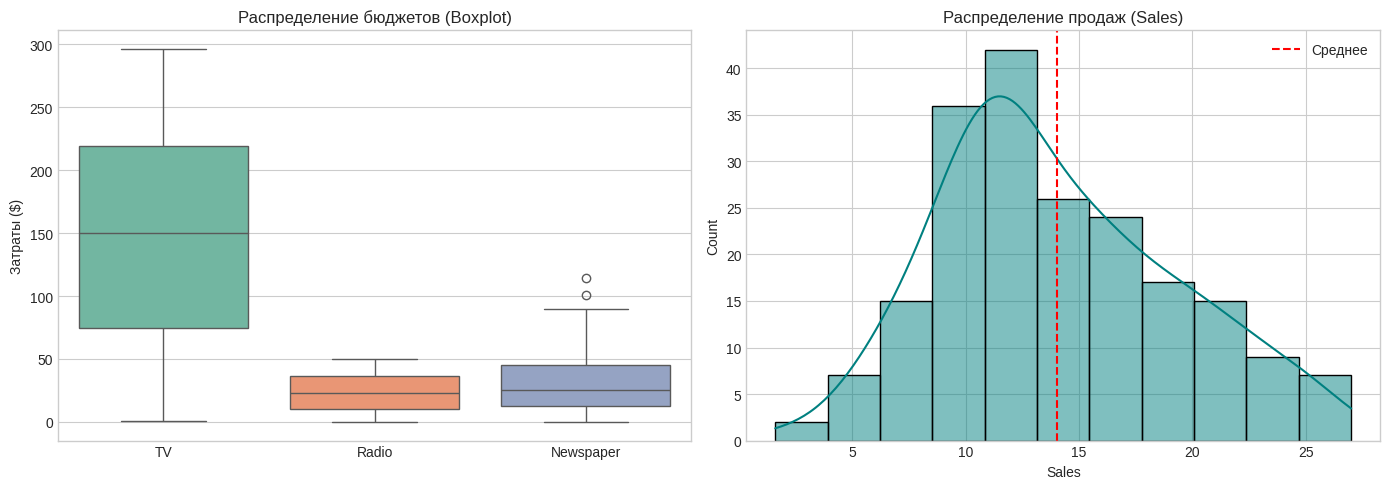

In [63]:
# Визуализация распределений и выбросов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot по каналам рекламы
sns.boxplot(data=df.drop('Sales', axis=1), ax=axes[0])
axes[0].set_title("Распределение бюджетов (Boxplot)")
axes[0].set_ylabel("Затраты ($)")

# Histogram продаж
sns.histplot(df['Sales'], kde=True, ax=axes[1], color='teal')
axes[1].axvline(df['Sales'].mean(), color='red', linestyle='--', label='Среднее')
axes[1].set_title("Распределение продаж (Sales)")
axes[1].legend()

plt.tight_layout()
plt.show()

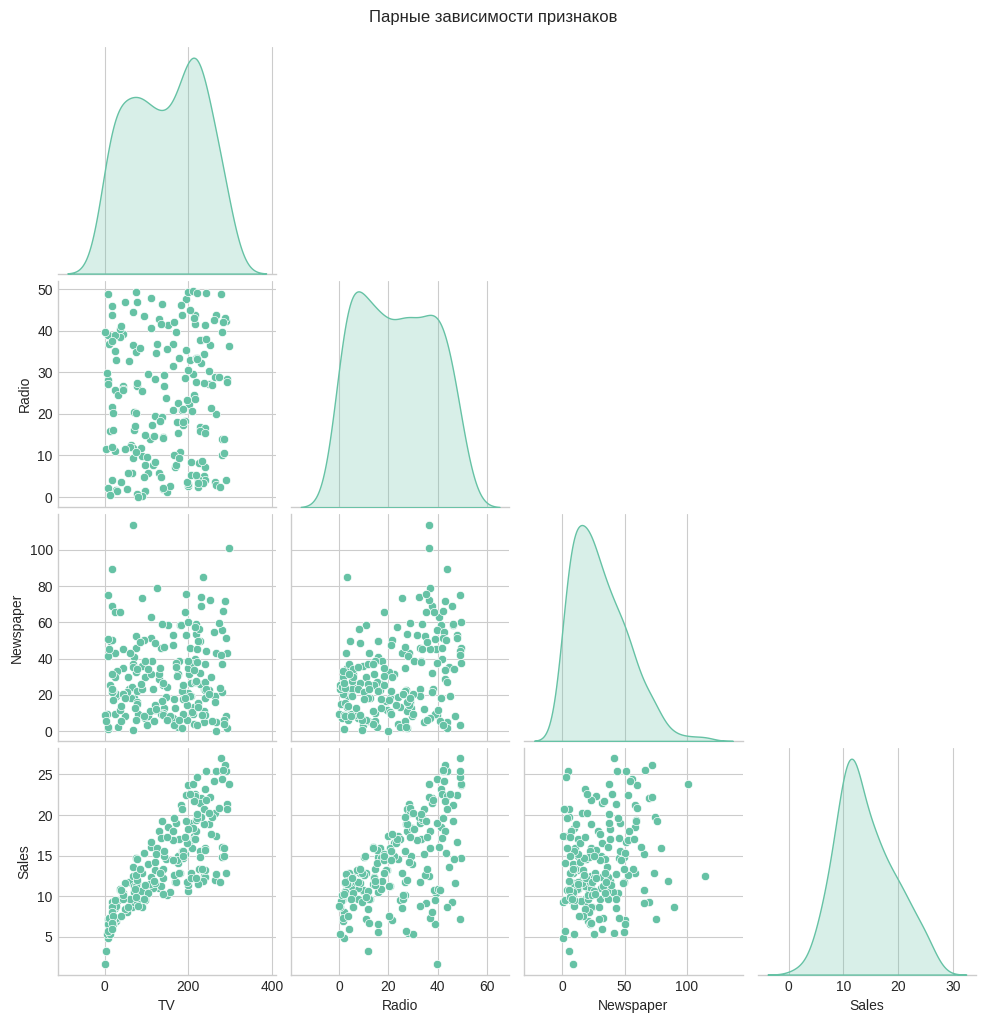

In [64]:
# Pairplot для визуальной оценки связей
sns.pairplot(df, diag_kind='kde', corner=True)
plt.suptitle("Парные зависимости признаков", y=1.02)
plt.show()

## Проверка предпосылок линейной регрессии
Для корректного применения МНК важно оценить:
- Нормальность распределения целевой переменной
- Линейность связи

Есть отклонения от нормальности, но при n=200 ЦПТ смягчает требования к остаткам



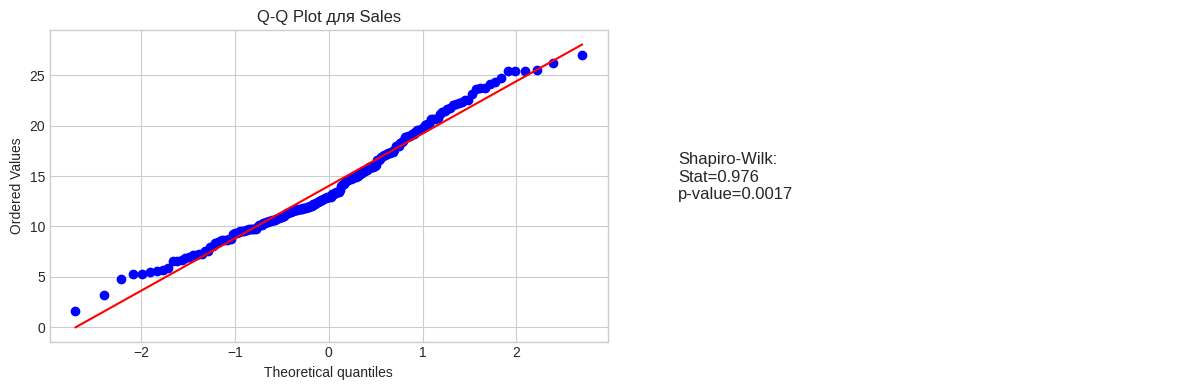

In [65]:
# Q-Q Plot и тест Шапиро-Уилка
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(df['Sales'], dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot для Sales")

shapiro_res = stats.shapiro(df['Sales'])
p_norm = shapiro_res.pvalue
if p_norm > 0.05:
    print("Распределение не противоречит нормальному (p > 0.05)")
else:
    print("Есть отклонения от нормальности, но при n=200 ЦПТ смягчает требования к остаткам")

print()
axes[1].axis('off')
axes[1].text(0.1, 0.5, f"Shapiro-Wilk:\nStat={shapiro_res.statistic:.3f}\np-value={p_norm:.4f}\n", fontsize=12, verticalalignment='center')
plt.tight_layout()
plt.show()

## Корреляционный анализ

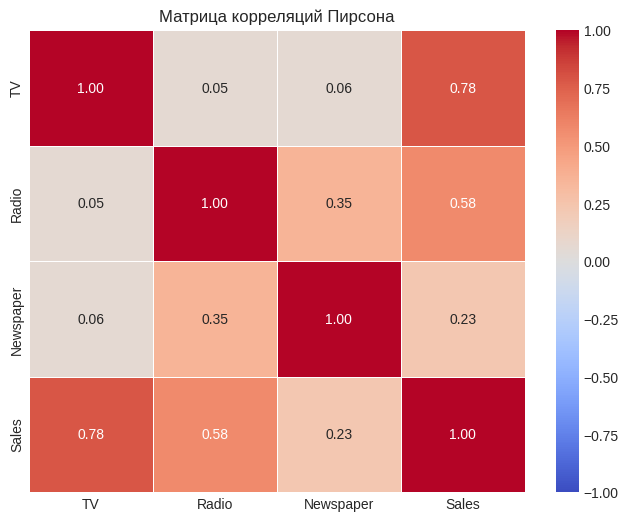

 Корреляция с Sales:
TV        : r = 0.782, p = 1.47e-42
Radio     : r = 0.576, p = 4.35e-19
Newspaper : r = 0.228, p = 1.15e-03


In [66]:
# Матрица корреляций
corr_matrix = df.corr(method='pearson')
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title("Матрица корреляций Пирсона")
plt.show()

# Коэффициенты для целевой переменной
print(" Корреляция с Sales:")
for col in ['TV', 'Radio', 'Newspaper']:
    r, p = stats.pearsonr(df[col], df['Sales'])
    print(f"{col:10s}: r = {r:.3f}, p = {p:.2e}")

## Регрессионный анализ
Построим модели, оценим их метрики и проанализируем остатки.

In [67]:
# Разделение на train/test (80/20)
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Train: {X_train.shape[0]} samples, test: {X_test.shape[0]} samples")

 Train: 160 samples, test: 40 samples


In [68]:
# Множественная линейная регрессия (OLS)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# Метрики качества
print(" Метрики модели (Test Set):")
print(f"R: {r2_score(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")

print("\n Коэффициенты модели:")
print(f"Intercept (bias): {lr.intercept_:.3f}")
for feat, coef in zip(X.columns, lr.coef_):
    print(f"{feat:10s}: {coef:+.4f} (продажи изменяются на {abs(coef):.3f} при росте бюджета на 1$)")

 Метрики модели (Test Set):
R: 0.899
MAE: 1.461
RMSE: 1.782

 Коэффициенты модели:
Intercept (bias): 2.979
TV        : +0.0447 (продажи изменяются на 0.045 при росте бюджета на 1$)
Radio     : +0.1892 (продажи изменяются на 0.189 при росте бюджета на 1$)
Newspaper : +0.0028 (продажи изменяются на 0.003 при росте бюджета на 1$)


In [69]:
# Детальный статистический вывод через statsmodels
X_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     446.6
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           2.53e-76
Time:                        17:44:05   Log-Likelihood:                -306.64
No. Observations:                 160   AIC:                             621.3
Df Residuals:                     156   BIC:                             633.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9791      0.354      8.427      0.0

## 6 Итоговые выводы и бизнес-рекомендации
### Ключевые наблюдения:
1. **TV** имеет самую высокую корреляцию с продажами (`r ≈ 0.78`). Коэффициент `≈ 0.046` означает, что вложение 1000$ в ТВ-рекламу приносит ~46 доп. продаж.
2. **Radio** (`r ≈ 0.58`, `coef ≈ 0.188`) показывает высокую отдачу на каждый вложенный доллар. При небольших бюджетах рентабельнее ТВ.
3. **Newspaper** статистически незначим (`p > 0.05`, коэффициент близок к нулю или отрицательный). Инвестиции в печатные СМИ не влияют на рост продаж в данном сегменте.

### Качество модели:
- `R² ≈ 0.90` → модель объясняет ~90% дисперсии продаж..

### Рекомендации бизнесу:
1. **Перераспределить бюджет**: Сократить или полностью убрать `Newspaper`. Перенаправить средства в `Radio` (для быстрого ROI) и `TV` (для масштабирования).
2. **Тестирование синергии**: Проверить гипотезу о комбинированном эффекте (например, ТВ + Radio одновременно могут давать нелинейный прирост).
3. **Расширение модели**: Добавить внешние факторы (сезонность, макроэкономические индикаторы, конкурентная активность) для повышения точности прогноза.
4. **A/B тесты**: Перед полным перераспределением бюджета запустить пилотные кампании в выбранных регионах.